# Dasheng — Glasgow micro-Doppler HAR Evaluation (k-NN & Linear Probing)

Evaluates `dasheng_base_spectrogram` on the Glasgow micro-Doppler HAR dataset using:
- **k-Nearest Neighbours (k-NN)** — zero-parameter probe
- **Linear probing** — frozen backbone + logistic regression

**Dataset:** 6-class HAR, pre-computed STFT micro-Doppler spectrograms, shape `(1024, 365)`, stored as `.npy` files.

**Protocol:** Stratified 5-fold cross-validation. Mean accuracy ± std reported across folds.

**Pipeline:** `.npy` → log1p → `DashengSpectrogram` (resize 1024→64, BN, patch-embed, transformer) → mean-pool → 768-d feature vector.

## 1. Imports & configuration

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print(f"torch : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

torch : 2.10.0+cu130
CUDA available: True
Using device: cuda


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT    = Path(".").resolve()
GLASGOW_ROOT = REPO_ROOT / "data" / "Glasgow"

# ── Class names ─────────────────────────────────────────────────────────────
CLASS_NAMES = {
    1: "Walking",
    2: "Sitting down",
    3: "Standing up",
    4: "Picking up object",
    5: "Drinking",
    6: "Falling",
}

# ── Model ──────────────────────────────────────────────────────────────────
MODEL_PATH = None   # set to "/path/to/dasheng_base.pt" to skip download

# ── Preprocessing ──────────────────────────────────────────────────────────
USE_LOG1P = True    # log1p brings linear-amplitude STFT closer to dB scale

# ── Cross-validation ───────────────────────────────────────────────────────
N_FOLDS = 5
CV_SEED = 42

# ── k-NN ───────────────────────────────────────────────────────────────────
KNN_K = 10

# ── Linear probe ───────────────────────────────────────────────────────────
LR_MAX_ITER = 1000
LR_C        = 1.0

assert GLASGOW_ROOT.exists(), f"Glasgow data not found: {GLASGOW_ROOT}"
print("Paths OK")

Paths OK


## 2. Load the pretrained Dasheng spectrogram model

In [3]:
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dasheng import dasheng_base_spectrogram

model = dasheng_base_spectrogram(path=MODEL_PATH)
model = model.eval().to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Loaded dasheng_base_spectrogram  ({n_params/1e6:.1f}M parameters)")
print(f"Input F will be interpolated to {model.n_mels}")

Loaded dasheng_base_spectrogram  (85.4M parameters)
Input F will be interpolated to 64


## 3. Inspect the dataset

In [4]:
def collect_dataset(root: Path) -> tuple[list[Path], np.ndarray]:
    """Collect all .npy files and integer labels from class subfolders."""
    files, labels = [], []
    for class_dir in sorted(root.iterdir(), key=lambda p: int(p.name)):
        if not class_dir.is_dir():
            continue
        cls = int(class_dir.name)
        npy_files = sorted(class_dir.glob("*.npy"))
        files.extend(npy_files)
        labels.extend([cls] * len(npy_files))
    return files, np.array(labels)


all_files, all_labels = collect_dataset(GLASGOW_ROOT)
print(f"Total: {len(all_files)} files, {len(set(all_labels))} classes")

dist = pd.DataFrame({
    "Class":    list(CLASS_NAMES.keys()),
    "Activity": list(CLASS_NAMES.values()),
    "Count":    [np.sum(all_labels == c) for c in CLASS_NAMES],
})
print()
print(dist.to_string(index=False))

Total: 2081 files, 6 classes

 Class          Activity  Count
     1           Walking    640
     2      Sitting down    312
     3       Standing up    311
     4 Picking up object    310
     5          Drinking    310
     6           Falling    198


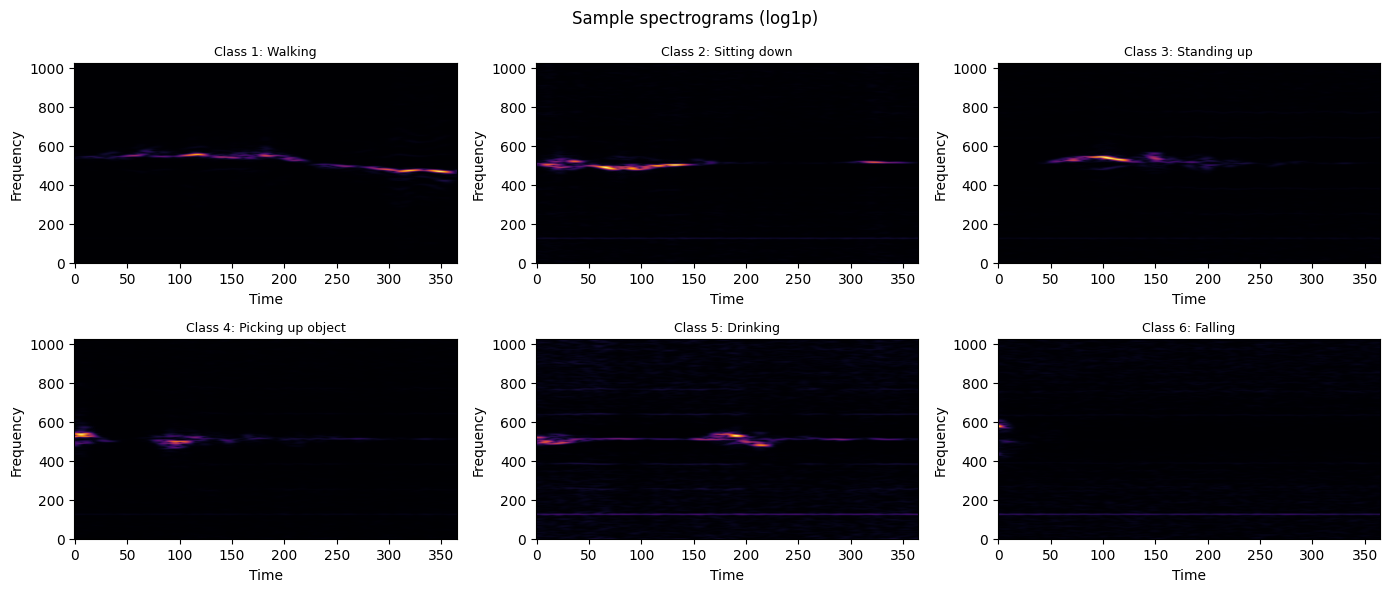

In [5]:
# Visualise one spectrogram per class
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, (cls, name) in zip(axes.flat, CLASS_NAMES.items()):
    sample_path = next(p for p, l in zip(all_files, all_labels) if l == cls)
    spec = np.load(sample_path)
    if USE_LOG1P:
        spec = np.log1p(spec)
    ax.imshow(spec, aspect="auto", origin="lower", cmap="inferno")
    ax.set_title(f"Class {cls}: {name}", fontsize=9)
    ax.set_xlabel("Time"); ax.set_ylabel("Frequency")
plt.suptitle("Sample spectrograms (log1p)" if USE_LOG1P else "Sample spectrograms (raw)")
plt.tight_layout()
plt.show()

## 4. Feature extraction

Extract features for the entire dataset once, then reuse them across all folds.

Each `.npy` spectrogram `(1024, 365)` → log1p → `DashengSpectrogram` (resize to `(64, 365)`, BN, transformer) → mean-pool tokens → `(768,)`.

In [6]:
@torch.inference_mode()
def extract_features(
    model: torch.nn.Module,
    files: list[Path],
    use_log1p: bool = True,
    device: torch.device = torch.device("cpu"),
) -> np.ndarray:
    """
    Returns:
        features : (N, D)  float32 numpy array
    """
    features = []
    for filepath in tqdm(files, desc="Extracting features"):
        spec = np.ascontiguousarray(np.load(filepath), dtype=np.float32)  # (F, T)
        if use_log1p:
            spec = np.log1p(spec)
        x = torch.from_numpy(spec).unsqueeze(0).to(device)  # (1, F, T)
        out = model(x)                                        # (1, N_patches, D)
        features.append(out.mean(dim=1).squeeze(0).cpu().float().numpy())
    return np.stack(features)


features = extract_features(model, all_files, USE_LOG1P, DEVICE)
print(f"Features shape: {features.shape}")

Extracting features: 100%|██████████| 2081/2081 [00:23<00:00, 87.14it/s]

Features shape: (2081, 768)


## 5. 5-fold cross-validation

In [7]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_SEED)

knn_accs, lr_accs = [], []
# Keep last fold predictions for the confusion matrix
last_y_true, last_knn_pred, last_lr_pred = None, None, None

for fold, (train_idx, test_idx) in enumerate(skf.split(features, all_labels), start=1):
    X_train, y_train = features[train_idx], all_labels[train_idx]
    X_test,  y_test  = features[test_idx],  all_labels[test_idx]

    # ── k-NN ───────────────────────────────────────────────────────────────
    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=KNN_K, metric="cosine")),
    ])
    knn_pipe.fit(X_train, y_train)
    knn_pred = knn_pipe.predict(X_test)
    knn_acc  = accuracy_score(y_test, knn_pred)
    knn_accs.append(knn_acc)

    # ── Linear probe ───────────────────────────────────────────────────────
    lr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(C=LR_C, max_iter=LR_MAX_ITER, solver="lbfgs")),
    ])
    lr_pipe.fit(X_train, y_train)
    lr_pred = lr_pipe.predict(X_test)
    lr_acc  = accuracy_score(y_test, lr_pred)
    lr_accs.append(lr_acc)

    print(f"Fold {fold} — k-NN: {knn_acc*100:.1f}%   LR: {lr_acc*100:.1f}%")
    last_y_true, last_knn_pred, last_lr_pred = y_test, knn_pred, lr_pred

print()
print(f"k-NN  (k={KNN_K}) : {np.mean(knn_accs)*100:.2f}% ± {np.std(knn_accs)*100:.2f}%")
print(f"Linear probe     : {np.mean(lr_accs)*100:.2f}% ± {np.std(lr_accs)*100:.2f}%")

Fold 1 — k-NN: 87.1%   LR: 90.6%
Fold 2 — k-NN: 85.1%   LR: 88.0%
Fold 3 — k-NN: 83.7%   LR: 88.5%
Fold 4 — k-NN: 84.4%   LR: 87.0%
Fold 5 — k-NN: 83.2%   LR: 86.8%

k-NN  (k=10) : 84.67% ± 1.36%
Linear probe     : 88.18% ± 1.38%


In [8]:
# Detailed classification report for the linear probe (last fold)
class_name_list = [CLASS_NAMES[c] for c in sorted(CLASS_NAMES)]
print(f"Classification report — Linear probe (fold {N_FOLDS})")
print(classification_report(last_y_true, last_lr_pred, target_names=class_name_list, digits=3))

Classification report — Linear probe (fold 5)
                   precision    recall  f1-score   support

          Walking      0.960     0.945     0.953       128
     Sitting down      0.909     0.968     0.938        62
      Standing up      0.918     0.903     0.911        62
Picking up object      0.676     0.774     0.722        62
         Drinking      0.776     0.613     0.685        62
          Falling      0.884     0.950     0.916        40

         accuracy                          0.868       416
        macro avg      0.854     0.859     0.854       416
     weighted avg      0.869     0.868     0.866       416



## 6. Confusion matrices (last fold)

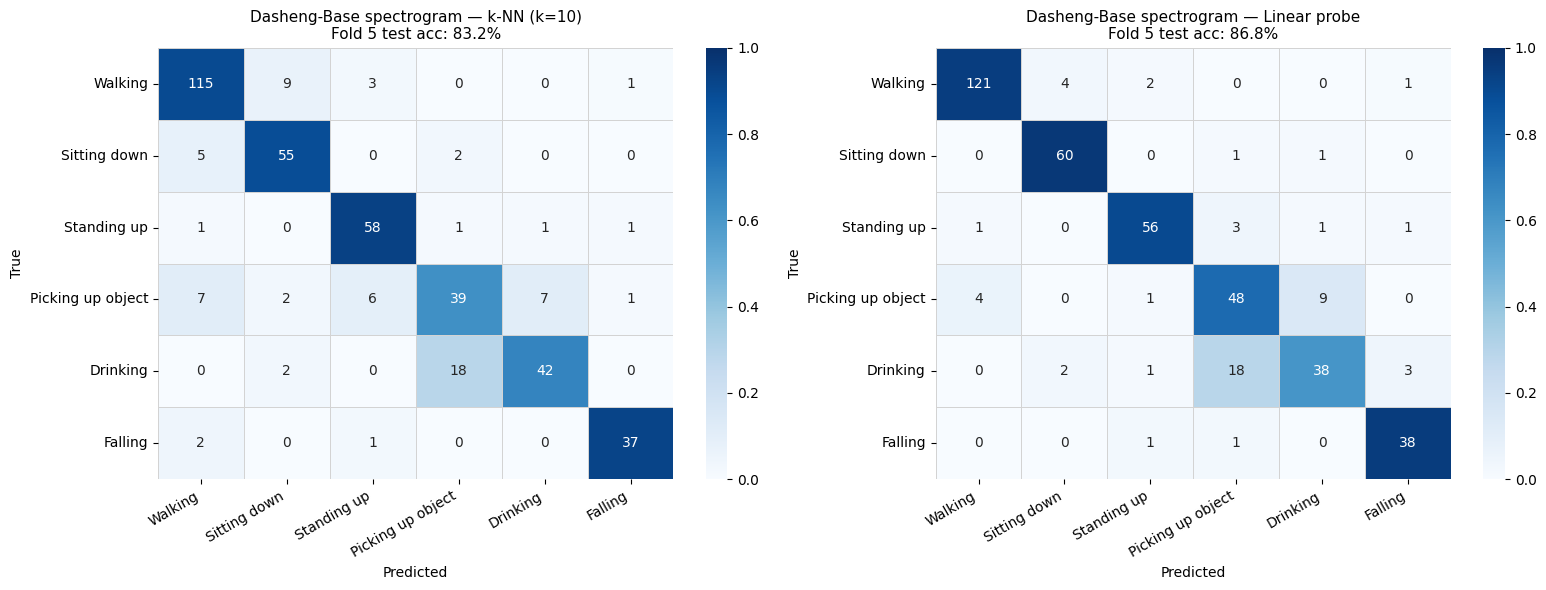

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pred, method, acc in zip(
    axes,
    [last_knn_pred, last_lr_pred],
    [f"k-NN (k={KNN_K})", "Linear probe"],
    [knn_accs[-1],        lr_accs[-1]],
):
    cm = confusion_matrix(last_y_true, pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised (recall)

    sns.heatmap(
        cm_norm,
        ax=ax,
        xticklabels=class_name_list,
        yticklabels=class_name_list,
        cmap="Blues",
        annot=cm,
        fmt="d",
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor="lightgrey",
    )
    ax.set_title(f"Dasheng-Base spectrogram — {method}\nFold {N_FOLDS} test acc: {acc*100:.1f}%", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("glasgow_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Per-class accuracy (across folds)

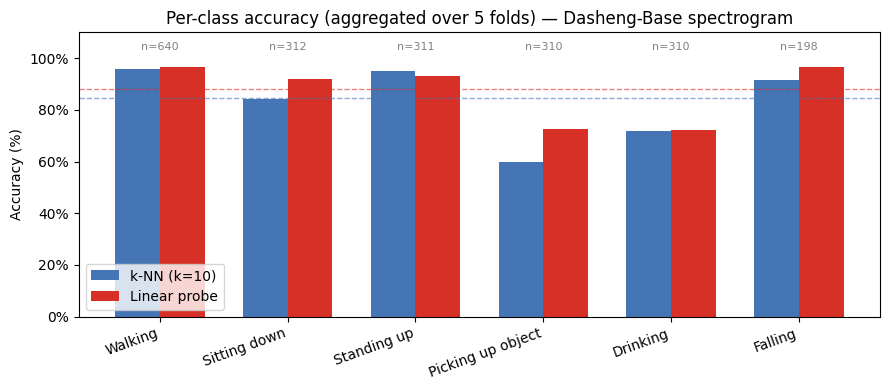

         Activity   n  k-NN  Linear
          Walking 640 0.958   0.966
     Sitting down 312 0.843   0.920
      Standing up 311 0.952   0.932
Picking up object 310 0.600   0.726
         Drinking 310 0.719   0.723
          Falling 198 0.914   0.965


In [10]:
# Rerun CV to collect all predictions (for aggregate per-class accuracy)
all_y_true, all_knn_pred, all_lr_pred = [], [], []

for train_idx, test_idx in skf.split(features, all_labels):
    X_train, y_train = features[train_idx], all_labels[train_idx]
    X_test,  y_test  = features[test_idx],  all_labels[test_idx]

    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=KNN_K, metric="cosine")),
    ])
    knn_pipe.fit(X_train, y_train)

    lr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(C=LR_C, max_iter=LR_MAX_ITER, solver="lbfgs")),
    ])
    lr_pipe.fit(X_train, y_train)

    all_y_true.extend(y_test)
    all_knn_pred.extend(knn_pipe.predict(X_test))
    all_lr_pred.extend(lr_pipe.predict(X_test))

all_y_true   = np.array(all_y_true)
all_knn_pred = np.array(all_knn_pred)
all_lr_pred  = np.array(all_lr_pred)

classes = sorted(CLASS_NAMES.keys())
per_class = pd.DataFrame({
    "Activity": [CLASS_NAMES[c] for c in classes],
    "n":        [np.sum(all_labels == c) for c in classes],
    "k-NN":     [accuracy_score(all_y_true[all_y_true == c], all_knn_pred[all_y_true == c]) for c in classes],
    "Linear":   [accuracy_score(all_y_true[all_y_true == c], all_lr_pred[all_y_true == c])  for c in classes],
})

x = np.arange(len(classes))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, per_class["k-NN"]  * 100, w, label=f"k-NN (k={KNN_K})",  color="#4575b4")
ax.bar(x + w/2, per_class["Linear"] * 100, w, label="Linear probe", color="#d73027")
ax.axhline(np.mean(knn_accs) * 100, color="#4575b4", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(np.mean(lr_accs)  * 100, color="#d73027", linestyle="--", linewidth=1, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(per_class["Activity"], rotation=20, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-class accuracy (aggregated over 5 folds) — Dasheng-Base spectrogram")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 110)
ax.legend()

for i, n in enumerate(per_class["n"]):
    ax.text(i, 103, f"n={n}", ha="center", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("glasgow_per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

print(per_class.to_string(index=False, float_format="{:.3f}".format))

## 8. Summary

In [11]:
summary = pd.DataFrame({
    "Method": [f"k-NN (k={KNN_K}, cosine)", "Linear probe (LR)"],
    "Mean acc (%)": [f"{np.mean(knn_accs)*100:.2f}", f"{np.mean(lr_accs)*100:.2f}"],
    "Std (%)": [f"{np.std(knn_accs)*100:.2f}", f"{np.std(lr_accs)*100:.2f}"],
    "Per-fold accs (%)": [
        ", ".join(f"{a*100:.1f}" for a in knn_accs),
        ", ".join(f"{a*100:.1f}" for a in lr_accs),
    ],
})
print("=" * 70)
print("  Dasheng-Base (spectrogram) — Glasgow HAR (5-fold CV)")
print("=" * 70)
print(summary.to_string(index=False))
print("=" * 70)
print(f"  Feature dim  : {features.shape[1]}")
print(f"  Input shape  : (F=1024, T=365) → resized to (F={model.n_mels}, T=365)")
print(f"  Preprocessing: {'log1p' if USE_LOG1P else 'none (raw linear amplitude)'}")
print(f"  Total samples: {len(all_files)}")
print(f"  CV seed      : {CV_SEED}")

  Dasheng-Base (spectrogram) — Glasgow HAR (5-fold CV)
             Method Mean acc (%) Std (%)            Per-fold accs (%)
k-NN (k=10, cosine)        84.67    1.36 87.1, 85.1, 83.7, 84.4, 83.2
  Linear probe (LR)        88.18    1.38 90.6, 88.0, 88.5, 87.0, 86.8
  Feature dim  : 768
  Input shape  : (F=1024, T=365) → resized to (F=64, T=365)
  Preprocessing: log1p
  Total samples: 2081
  CV seed      : 42
